# Import libraries

In [1]:
import pandas as pd 
import seaborn as sns
from matplotlib import pyplot as plt

# CometML Configuration

In [ ]:
# !pip install comet_ml

  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/787.0 kB ? eta -:--:--
   ---------------------------------------- 787.0/787.0 kB 9.8 MB/s  0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 11.6 MB/s  0:00:00
Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl (18 kB)
Using cached referencing-0.37.0-py3-none-any.whl (26 kB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)

   ------ ---------------------------------  3/20 [simplejson]
   -------- -------------------------------  4/20 [setuptools]
   -------- -------------------------------  4/20 [setuptools]
   -------- -------------------------------  4/20 [setuptools]
   -------- -------------------------------  4/


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from comet_ml import Experiment

In [ ]:
# Create an experiment using your API key
experiment = Experiment(
    api_key='',
    project_name='',
    workspace='',
)

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/azudilins/medical-appointment/97f244acbc0b46f19476d8d8921f59f6



# Loading data

In [51]:
df = pd.read_csv('data/KaggleV2-May-2016.csv')

In [52]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


# Visualization

### Distribution of numerical features

{'web': 'https://www.comet.com/api/image/download?imageId=708d6ffb4b734a8499075cae34efdbcc&experimentKey=97f244acbc0b46f19476d8d8921f59f6',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=708d6ffb4b734a8499075cae34efdbcc&experimentKey=97f244acbc0b46f19476d8d8921f59f6',
 'imageId': '708d6ffb4b734a8499075cae34efdbcc'}

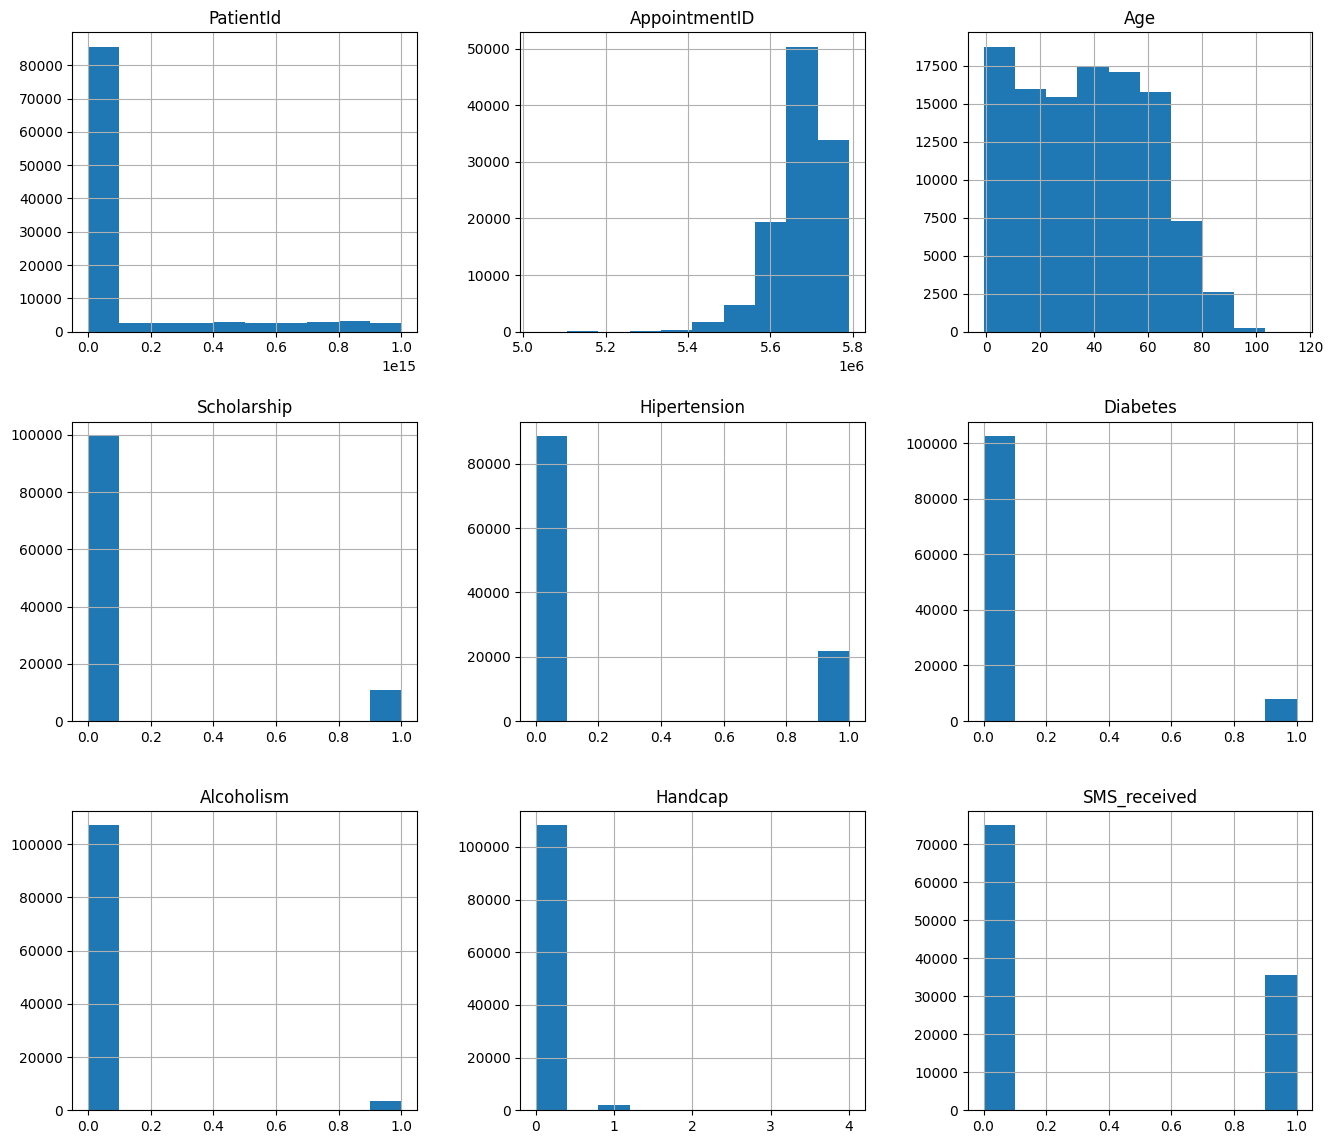

In [9]:
df.hist(figsize=(16,14));

# log the histogram
experiment.log_figure(figure=plt)

*Let's analyze the number of people of each age*

In [10]:
print("Unique values ​​in `Age` => {}".format(df.Age.unique()))

Unique values ​​in `Age` => [ 62  56   8  76  23  39  21  19  30  29  22  28  54  15  50  40  46   4
  13  65  45  51  32  12  61  38  79  18  63  64  85  59  55  71  49  78
  31  58  27   6   2  11   7   0   3   1  69  68  60  67  36  10  35  20
  26  34  33  16  42   5  47  17  41  44  37  24  66  77  81  70  53  75
  73  52  74  43  89  57  14   9  48  83  72  25  80  87  88  84  82  90
  94  86  91  98  92  96  93  95  97 102 115 100  99  -1]


In [53]:
# Remove outliers
df = df[(df.Age >= 0) & (df.Age <= 110)]
df.Age.value_counts()

Age
0      3539
1      2273
52     1746
49     1652
53     1651
       ... 
97       11
98        6
100       4
102       2
99        1
Name: count, Length: 102, dtype: int64

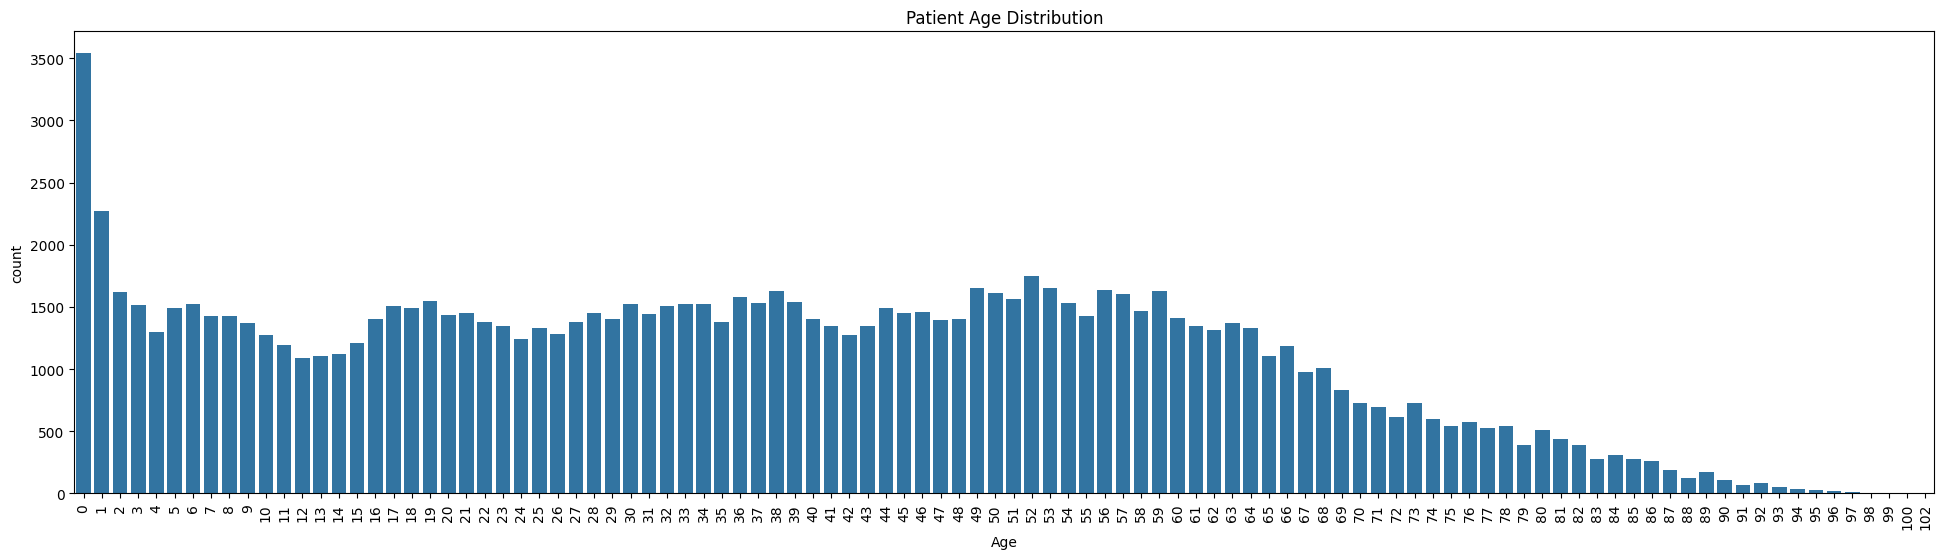

In [14]:
plt.figure(figsize=(24,6))
plt.xticks(rotation=90)
ax = sns.countplot(x=df.Age)
ax.set_title("Patient Age Distribution")
experiment.log_figure(figure=plt)
plt.show()

# Will the patient come to the scheduled appointment?

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110521 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110521 non-null  float64
 1   AppointmentID   110521 non-null  int64  
 2   Gender          110521 non-null  object 
 3   ScheduledDay    110521 non-null  object 
 4   AppointmentDay  110521 non-null  object 
 5   Age             110521 non-null  int64  
 6   Neighbourhood   110521 non-null  object 
 7   Scholarship     110521 non-null  int64  
 8   Hipertension    110521 non-null  int64  
 9   Diabetes        110521 non-null  int64  
 10  Alcoholism      110521 non-null  int64  
 11  Handcap         110521 non-null  int64  
 12  SMS_received    110521 non-null  int64  
 13  No-show         110521 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 12.6+ MB


## Encoding of categorical features

In [16]:
categorical_columns_names = ['Gender', 'Neighbourhood']

In [17]:
encoded_columns = pd.get_dummies(df, columns = categorical_columns_names)

In [18]:
encoded_columns.drop(['AppointmentID', 'PatientId', 'ScheduledDay', 'AppointmentDay', 'No-show'], axis=1, inplace = True)

In [19]:
encoded_columns.head()

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Gender_F,Gender_M,Neighbourhood_AEROPORTO,...,Neighbourhood_SANTOS REIS,Neighbourhood_SEGURANÇA DO LAR,Neighbourhood_SOLON BORGES,Neighbourhood_SÃO BENEDITO,Neighbourhood_SÃO CRISTÓVÃO,Neighbourhood_SÃO JOSÉ,Neighbourhood_SÃO PEDRO,Neighbourhood_TABUAZEIRO,Neighbourhood_UNIVERSITÁRIO,Neighbourhood_VILA RUBIM
0,62,0,1,0,0,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,56,0,0,0,0,0,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,62,0,0,0,0,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,8,0,0,0,0,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,56,0,1,1,0,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [20]:
y = df['No-show']

In [21]:
y

0         No
1         No
2         No
3         No
4         No
          ..
110522    No
110523    No
110524    No
110525    No
110526    No
Name: No-show, Length: 110521, dtype: object

In [22]:
y = y.replace({'No': 0, 'Yes': 1})

C:\Users\azudi\AppData\Local\Temp\ipykernel_10708\3050984062.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'No': 0, 'Yes': 1})


In [23]:
y.value_counts(True)

No-show
0    0.798084
1    0.201916
Name: proportion, dtype: float64

## Data scaling

In [ ]:
# !pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
 


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from sklearn.preprocessing import MinMaxScaler

In [27]:
scaler = MinMaxScaler()
X = scaler.fit_transform(encoded_columns)

In [28]:
print(X.shape)

(110521, 90)


# Model (this section will be covered in detail later in the course)

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Model initialization

In [30]:
logreg = LogisticRegression()

In [31]:
random_state = 42

### Model training

In [32]:
logreg.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Logging training parameters

In [33]:
params={"random_state":random_state,
        "model_type":"logreg"
}

In [34]:
experiment.log_parameters(params)

### Model predictions

In [35]:
y_pred = logreg.predict(X)

### Model analysis

In [36]:
accuracy = accuracy_score(y, y_pred)

print("Percentage of correct answers: {:6.3f}".format(accuracy))

Percentage of correct answers:  0.798


# Logging metrics

In [37]:
metrics = {"accuracy":accuracy}

In [38]:
experiment.log_metrics(metrics)

<img src = 'https://miro.medium.com/max/1400/0*r2yYhe2DpE4d3WKP.png' width=700px>

In [39]:
experiment.log_confusion_matrix(y.tolist(), y_pred.tolist())

{'web': 'https://www.comet.com/api/asset/download?assetId=11d73f7e31b94c1b929912f39e5db2ab&experimentKey=97f244acbc0b46f19476d8d8921f59f6',
 'api': 'https://www.comet.com/api/rest/v2/experiment/asset/get-asset?assetId=11d73f7e31b94c1b929912f39e5db2ab&experimentKey=97f244acbc0b46f19476d8d8921f59f6',
 'assetId': '11d73f7e31b94c1b929912f39e5db2ab'}

In [40]:
experiment.display()

In [41]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : artificial_neutron_9884
COMET INFO:     url                   : https://www.comet.com/azudilins/medical-appointment/97f244acbc0b46f19476d8d8921f59f6
COMET INFO:   Metrics:


COMET INFO:     accuracy : 0.7980836221170637
COMET INFO:   Parameters:
COMET INFO:     C                 : 1.0
COMET INFO:     class_weight      : None
COMET INFO:     clip              : False
COMET INFO:     copy              : True
COMET INFO:     dual              : False
COMET INFO:     feature_range     : (0, 1)
COMET INFO:     fit_intercept     : True
COMET INFO:     intercept_scaling : 1
COMET INFO:     l1_ratio          : 0.0
COMET INFO:     max_iter          : 100
COMET INFO:     model_type        : logreg
COMET INFO:     n_jobs            : None
COMET INFO:     penalty           : deprecated
COMET INFO:     random_state      : 42
COMET INFO:     solver            : lbfgs
COMET INFO:     tol               : 0.0001
COMET INFO:     verbose           : 0
COMET INFO:     warm_start        : False
COMET INFO:   Uploads:
COMET INFO:     confusion-matrix    : 1
COMET INFO:     environment details : 1
COMET INFO:     figures             : 3
COMET INFO:     filename            : 1
CO

# Homework

Visualize the correlation between the numerical features used to train the model and log the image in Comet.

Please attach an updated laptop as your answer.

*Mentor evaluation form:*

1) Visualized the correlation between the 7 numerical features used to train the model - 5 points

2) Logged the graph in CometML - 10 points

In [ ]:
# Create an experiment using an API key
experiment = Experiment(
    api_key='',
    project_name='',
    workspace=''
)

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/azudilins/medical-appointment/7caa69fb667e425b9552b3b0248f682f



In [55]:
# remove unnecessary columns from the table
df.drop(['AppointmentID', 'PatientId', 'ScheduledDay', 'AppointmentDay', 'No-show', 'Gender', 'Neighbourhood'], axis=1, inplace=True)

In [56]:
# we check the data
df.head()

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
0,62,0,1,0,0,0,0
1,56,0,0,0,0,0,0
2,62,0,0,0,0,0,0
3,8,0,0,0,0,0,0
4,56,0,1,1,0,0,0


For the calculation, we will use the Spearman correlation, since we are dealing with categorical features, and also because we have cleared the "Age" column of outliers.

{'web': 'https://www.comet.com/api/image/download?imageId=1c304a6b9b644a4baa510646027a1aa9&experimentKey=7caa69fb667e425b9552b3b0248f682f',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=1c304a6b9b644a4baa510646027a1aa9&experimentKey=7caa69fb667e425b9552b3b0248f682f',
 'imageId': '1c304a6b9b644a4baa510646027a1aa9'}

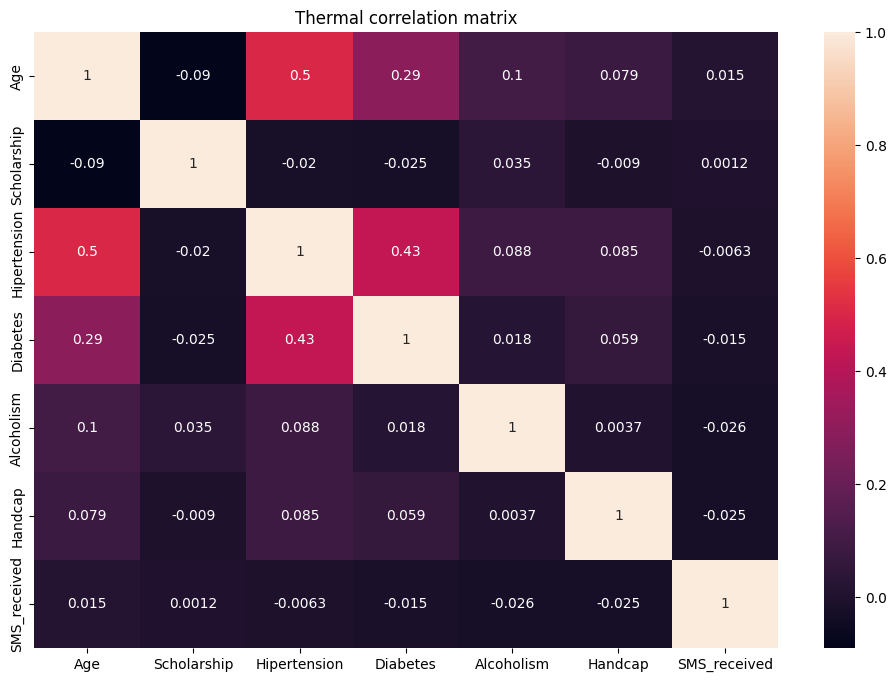

In [57]:
# visualizing the correlation
plt.figure(figsize=(12, 8))
ax = sns.heatmap(df.corr(method='spearman'), annot=True)
ax.set_title('Thermal correlation matrix');
# we log the graph
experiment.log_figure(figure=plt)

In [58]:
# выводим информацию
experiment.display()

In [59]:
# завершаем эксперимент
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : grateful_spire_2202
COMET INFO:     url                   : https://www.comet.com/azudilins/medical-appointment/7caa69fb667e425b9552b3b0248f682f
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     figures             : 1
COMET INFO:     filename            : 1
COMET INFO:     git metadata        : 1
COMET INFO:     installed packages  : 1
COMET INFO:     notebook            : 1
COMET INFO:     source_code         : 1
COMET INFO: 
